# ***1. Unpacking (Desempacotamento)***

Usar o método .items() com o 'for' e o 'in' é uma das construções mais elegantes do Python. É o que chamamos de Unpacking (Desempacotamento) dentro de um laço.

## Como funciona o .items()
O método .items() não retorna apenas o valor ou a chave, ele retorna ambos agrupados em uma tupla. Quando você usa o for, o Python "desmembra" essa tupla automaticamente para você.

In [1]:
notas = {
    "Alice": 9.5,
    "Bruno": 7.0,
    "Carla": 10.0
}

# Em vez de pegar só um, pegamos 'chave' e 'valor' (nome e nota)
for nome, nota in notas.items():
    status = "Aprovado" if nota >= 7 else "Recuperação"
    print(f"Aluno: {nome} | Nota: {nota} | Status: {status}")

Aluno: Alice | Nota: 9.5 | Status: Aprovado
Aluno: Bruno | Nota: 7.0 | Status: Aprovado
Aluno: Carla | Nota: 10.0 | Status: Aprovado


## Por que isso funciona?

1. notas.items(): Retorna algo como [('Alice', 9.5), ('Bruno', 7.0), ...].

2. for nome, nota: Em cada volta do laço, o Python vê a tupla ('Alice', 9.5) e faz:

    - nome = "Alice"

    - nota = 9.5

3. O in: Aqui ele serve como o motor de iteração, dizendo ao for para percorrer cada par gerado pelo método.

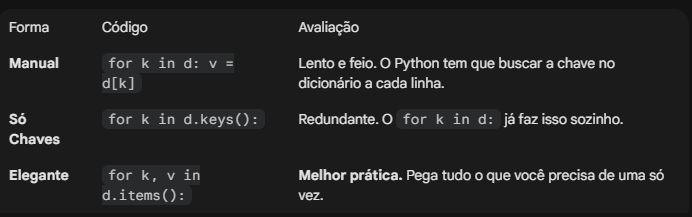

----------------------------------------------------------------------------------------------------

# ***2. Destrinchando um trecho do código***

In [3]:
z = (10, 20)

x, y = z

print(f"x agora é {x} e y agora é {y} que estão na Lista z: {z}")

x agora é 10 e y agora é 20 que estão na Lista z: (10, 20)


Posso nomear diretamente os index de uma estrutura de dado (neste caso, uma lista), dessa forma

----------------------------------------------------------------------------------------------------

# ***3. Utilização do operador/palavra chave 'and', 'not' e 'or'***

Uma observação a considerar... 

Em Python, em um dada situação que seja semelhante a esta:

In [ ]:
if opt != "1" and opt != "2":
    print("Opção inválida!")

Perceba que eu tive que dizer ao Python, duas situações entre o 'and', tento inclusive que repetir as variaveis e os sinais de '!='.

Essa é a forma correta de utiizar os operadores lógicos ('and', neste caso) porque, é como se fizessemos da seguinte maneira:

In [ ]:
if (opt != "1") and (opt != "2"):
    print("Opção inválida!")

E o motivo dessa observação é que, por motivos de querermos nos assemelhar a nossa língua, poderiamos querer escrever o código da seguinte maneira:

In [ ]:
if opt != "1" and != "2":
    print("Opção inválida!")

----------------------------------------------------------------------------------------------------

# ***4. Pensando no tempo de processamento de um código***

Análise o seguinte código:

In [1]:
lista_3 = [10.0, 'xx', True]
lista_4 = [0, False, 'xx']

elemento_em_comum = False # Crio uma sentinela que será esponsável por avisar se algo é igual

for valor_3 in lista_3:
    for valor_4 in lista_4:

        if valor_3 == valor_4:
            elemento_em_comum = True
            
            print(elemento_em_comum, f": O valor igual entre as listas é {valor_3}")



True : O valor igual entre as listas é xx


Não há nada de errado nele. O ponto é levantarmos a questão do processamento para uma determinada situação:

Imagine que nas duas listas usadas a cima, não houvesse 3 elementos em cada uma, mas sim milhões. O código quer analisar elemento por elemento e dizer se há algum deles que sejam iguais de uma lista para outra.

Desse modo, iria demorar muito tempo de análise. Portanto, podemos fazer uma pequena alteração:

In [2]:
# Diminuindo o tempo de processamento. Suponhamos que nessas listas abaixo, houvessem milhões de elementos em cada uma; isso levaria muito mais tempo para processar, portanto vamos fazer da seguinte maneira:

lista_3 = [10.0, 'xx', True]
lista_4 = [0, False, 'xx']

elemento_em_comum = False # Crio uma sentinela que será esponsável por avisar se algo é igual

for valor_3 in lista_3:
    if elemento_em_comum:
        break
    for valor_4 in lista_4:

        if valor_3 == valor_4:
            elemento_em_comum = True
            break
            
print(elemento_em_comum)

True


Perceba que se ele encontrar algo de igual, ele irá parar com o uso do 'break'. O que diminuí e muito o tempo de processamento.

Lembrando que isso aqui é para ajudar você a entender que esse tipo de coisa deve ser considerada. Não que aqui há uma receita de bolo, também; há casos e casos. Mas você, como programador, deve considerar esses pontos.

----------------------------------------------------------------------------------------------------

# ***5. Args e Kwargs***

Esse código é um excelente exemplo de como o Python lida com argumentos flexíveis. Ele permite que você passe quantos versos quiser e quantas informações extras (metadados) desejar, sem precisar mudar a estrutura da função.

In [2]:
def exibir_poema(data_extenso, *args, **kwargs):

    texto = "\n".join(args)

    meta_dados = "\n".join([f"{chave.title()}: {valor}" for chave, valor in kwargs.items()])

    # Edição da mensagem e como ela será apresentada:

    mensagem = f"{data_extenso}\n\n{texto}\n\n{meta_dados}"

    print(mensagem)

Vamos decompor cada linha:

1. A Assinatura da Função
def exibir_poema(data_extenso, *args, **kwargs):

- data_extenso: Um argumento obrigatório (posicional). No seu exemplo, ele recebe "Zen of Python".

- *args: O asterisco indica que a função pode receber múltiplos argumentos extras sem nome. Eles são armazenados em uma tupla. No exemplo, é o verso "Beautiful is better than ugly.".

- **kwargs: Os dois asteriscos indicam "keyword arguments" (argumentos nomeados). Eles são armazenados em um dicionário. No exemplo, são autor e ano.

2. Processando o Texto (*args)
texto = "\n".join(args)

Aqui, o código pega todos os versos enviados via *args e os junta em uma única string, separando cada um por uma quebra de linha (\n). Se você tivesse passado 10 versos, eles seriam empilhados aqui.

3. Processando os Metadados (**kwargs)
meta_dados = "\n".join([f"{chave.title()}: {valor}" for chave, valor in kwargs.items()])

Essa linha usa uma List Comprehension para varrer o dicionário de metadados:

- chave.title(): Pega o nome do argumento (ex: "autor") e coloca a primeira letra em maiúscula ("Autor").

- valor: Pega o conteúdo (ex: "Tim Peters").

- O resultado final é uma string formatada como Autor: Tim Peters e Ano: 1999, também separados por quebras de linha.

4. Montagem e Exibição
mensagem = f"{data_extenso}\n\n{texto}\n\n{meta_dados}"
print(mensagem)

O código utiliza uma f-string para organizar o layout final: o título no topo, os versos no meio e as informações extras no rodapé, separados por linhas em branco.

Dica: Tente adicionar mais versos e novos campos (como idioma = "Inglês") na chamada da função para ver como o código se adapta automaticamente!

----------------------------------------------------------------------------------------------------

# ***6. Hierarquia e o fluxo de dado***

Proponho ler uma linha de código como se fosse uma frase em português, assim aprendendo de vez o processo de acessos que o Python possui e permite com suas bibliotecas.

Ler o código como uma frase ajuda a entender a hierarquia e o fluxo de dados dentro do Python e da biblioteca 'Pandas' que usaremos por haver a necessidade de vários "acessos" para a execução de algo.

Veja o código abaxio:

In [ ]:
df["Cidade"].value_counts().plot.bar(title = "Total vendas por Cidade")

Embora ele esteja sem contexto e não funcionará pois nós não importamos as bibliotecas necessárias, queremos utiliza-lo para um estudo de caso.

Repare como esta linha de código possuí várias ações.

Vamos "traduzi-lo" para o português, assim entenderemos cada parte dessa linha de código:

*"Passe no meu arquivo (df), pegue a coluna de cidades (["Cidade"]), conte quantas vezes cada cidade aparece (value_counts()), prepare um gráfico (plot) do tipo barras (bar) e coloque o título 'Total vendas por Cidade' (title = "...")."*

Destrinchando:
- "Passe no meu arquivo (df), 
- pegue a coluna de cidades (["Cidade"]), 
- conte quantas vezes cada cidade aparece (value_counts()), 
- prepare um gráfico (plot);
- do tipo barras (bar);
- e coloque o título 'Total vendas por Cidade' (title = "...").";

### ***Por que tantos pontos? (O conceito de "Encadeamento")***

Você achava que depois de um ponto sempre vinha um método, e você não está errado! O que acontece aqui é o Encadeamento de Métodos (Method Chaining).

Imagine uma linha de produção em uma fábrica: o produto sai de uma máquina e entra direto na outra. Em Python, o ponto . conecta essas máquinas.

1. df["Cidade"]: Retorna um objeto do tipo Série (uma coluna).

2. .value_counts(): É um método que atua sobre a Série e retorna uma nova Série (com os totais).

3. .plot: Aqui está o segredo! O .plot não é exatamente um método final, ele é um acessor (como o .dt que vimos antes). Ele serve para agrupar todas as ferramentas de desenho em um só lugar.

4. .bar(): Este é o método final que diz como desenhar.

### ***Por que .plot.bar() e não apenas .plot_bar()?***
O Pandas usa essa estrutura para organizar a "caixa de ferramentas". Pense no .plot como uma gaveta. Dentro da gaveta de "Gráficos" (plot), você tem várias ferramentas:

- .bar() (barras)

- .pie() (pizza)

- .hist() (histograma)

- .line() (linhas)

Se o Pandas colocasse tudo direto no objeto principal, ele ficaria bagunçado. Ao usar .plot.bar(), o código fica mais organizado e fácil de ler (para quem já conhece a estrutura).

O Ponto de Separação: Regra de Ouro
Sempre que você vê um ponto, o que vem à esquerda dele é o "Dono" e o que vem à direita é a "Propriedade" ou "Ação".

- Carro.motor (O motor pertence ao carro - Atributo)

- Carro.ligar() (A ação de ligar pertence ao carro - Método)

- df.plot.bar() -> bar pertence à gaveta plot, que por sua vez pertence aos dados processados pelo df.

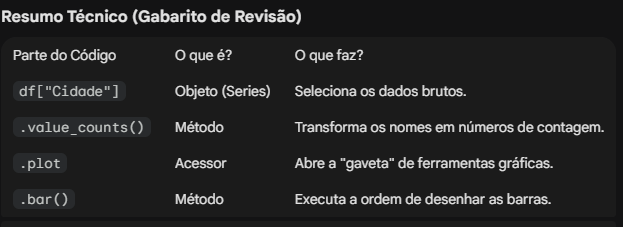